In [1]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [3]:

data = pd.read_csv(r"C:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\apple_feature_engineered.csv")

In [4]:
data

,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target,...,Negative_Sentiment,Neutral_Sentiment,article_count,Lag1,Lag2,Lag3,Lag5,RSI,MACD,Signal_Line
0,2017-10-05,36.193485,36.205132,35.881373,35.911650,85135200,0.012445,36.335905,36.659574,36.172497,...,0.008,0.9250,1.0,35.748585,35.981518,35.825451,35.702003,38.064917,-0.284222,-0.258333
1,2017-11-27,40.694866,40.926288,40.519548,40.919275,82867200,-0.005029,40.163732,37.868176,40.456429,...,0.008,0.9260,1.0,40.900558,40.898220,40.472790,39.773842,51.324818,0.770903,0.825436
2,2017-11-30,40.171238,40.239026,39.374124,39.839299,166108800,0.013984,40.322109,38.067460,39.984238,...,0.021,0.8040,1.0,39.617229,40.456429,40.694866,40.898220,42.328513,0.570635,0.728934
3,2018-01-31,39.138016,39.374113,38.920623,39.007112,129915600,0.002755,40.695436,40.410276,39.219841,...,0.009,0.9370,1.0,39.030506,39.261925,40.091763,40.725227,33.186061,-0.231234,0.065413
4,2018-03-16,41.783184,42.041364,41.689298,41.931049,157618800,-0.003526,41.453182,40.421219,41.144764,...,0.011,0.9170,1.0,41.931046,41.881760,42.240883,42.243217,47.417043,0.583631,0.574672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,2024-11-20,227.546204,228.470292,224.455947,226.612169,35169600,0.003154,225.555836,225.823628,227.069260,...,0.000,1.0000,2.0,226.830750,226.572433,223.571594,223.690811,56.669074,-0.197119,-0.491374
1128,2024-11-22,228.410660,229.255270,226.612153,226.612153,38168300,0.005907,225.402699,226.094087,231.391617,...,0.000,0.8705,2.0,227.069260,227.546204,226.830750,223.571594,67.646288,0.146823,-0.295464
1129,2024-11-25,231.391617,231.769209,228.281498,229.990580,90152800,0.013051,225.389111,226.427710,233.567719,...,0.000,1.0000,1.0,228.410660,227.069260,227.546204,226.572433,69.706436,0.548656,-0.126640
1130,2024-11-26,233.567719,234.074490,231.848706,231.848706,45986200,0.009404,225.470928,226.795525,233.438538,...,0.000,1.0000,4.0,231.391617,228.410660,227.069260,226.830750,74.215676,1.030822,0.104853


In [5]:
print(data.tail())

            Date       Close        High         Low        Open    Volume  \
1127  2024-11-20  227.546204  228.470292  224.455947  226.612169  35169600   
1128  2024-11-22  228.410660  229.255270  226.612153  226.612153  38168300   
1129  2024-11-25  231.391617  231.769209  228.281498  229.990580  90152800   
1130  2024-11-26  233.567719  234.074490  231.848706  231.848706  45986200   
1131  2024-11-27  233.438538  234.193722  232.325653  232.981466  33498400   

      Daily_Return        MA20        MA50      Target  ...  \
1127      0.003154  225.555836  225.823628  227.069260  ...   
1128      0.005907  225.402699  226.094087  231.391617  ...   
1129      0.013051  225.389111  226.427710  233.567719  ...   
1130      0.009404  225.470928  226.795525  233.438538  ...   
1131     -0.000553  225.723458  227.083336  235.823303  ...   

      Negative_Sentiment  Neutral_Sentiment  article_count        Lag1  \
1127                 0.0             1.0000            2.0  226.830750   
1128

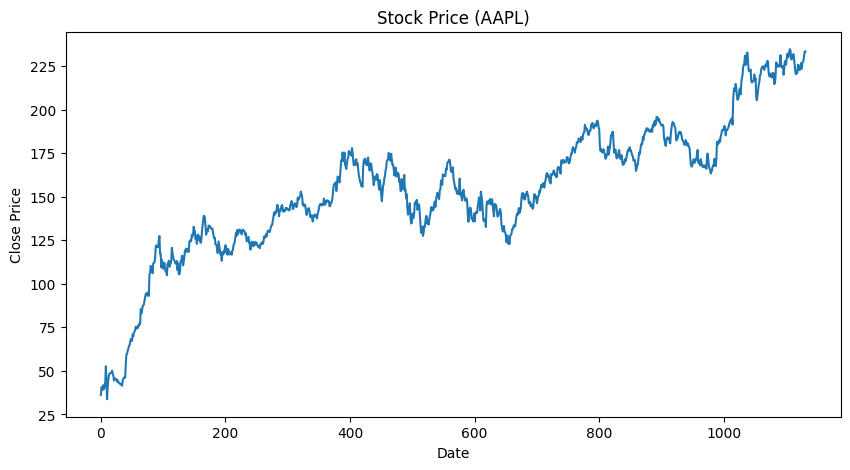

In [6]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Price (AAPL)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [7]:
data['Prediction'] = data['Close'].shift(-1)




In [8]:
data['Lag1'] = data['Close'].shift(1)
data['Lag2'] = data['Close'].shift(2)
data['Lag3'] = data['Close'].shift(3)
data['Lag4'] = data['Close'].shift(4)
data['Lag5'] = data['Close'].shift(5)

In [9]:
data = data.dropna()

In [10]:
X = data[['Close', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']]
y = data['Prediction']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
predictions = model.predict(X_test)


In [14]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 8.718895683312292
RMSE: 2.9527776217169306


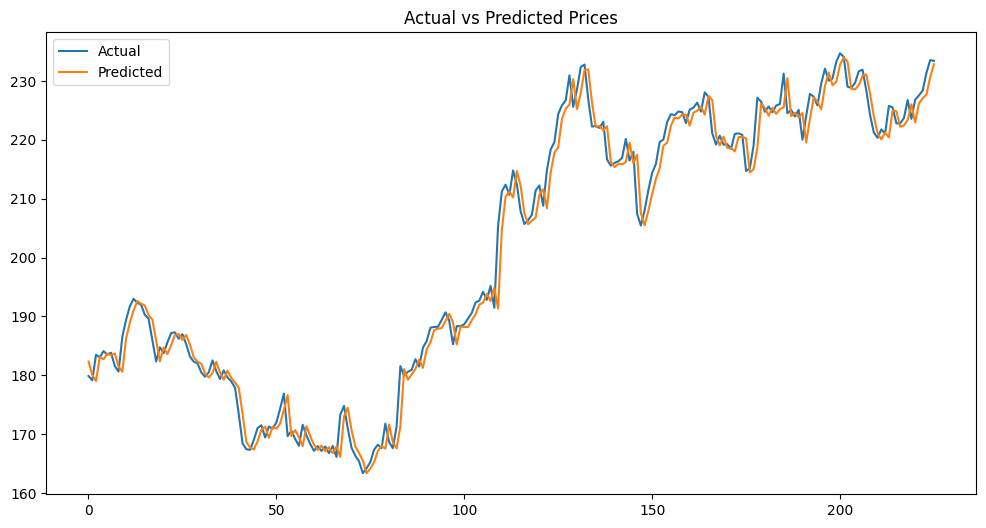

In [15]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

In [16]:
latest_features = X.iloc[-1].values.reshape(1, -1)

predicted_today_price = model.predict(latest_features)

print("Predicted Today's Close Price:", predicted_today_price[0])

Predicted Today's Close Price: 232.8711836535662


c:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
last_predicted = predictions[-1]
last_actual = y_test.iloc[-1]
last_date = y_test.index[-1]

In [18]:
error = abs(last_actual - last_predicted)
percentage_error = (error / last_actual) * 100

In [19]:
print("\n===== Yesterday Prediction Check =====")
print("Date:", last_date)
print("Predicted Price:", last_predicted)
print("Actual Price:", last_actual)
print("Absolute Error:", error)
print("Percentage Error:", percentage_error, "%")


===== Yesterday Prediction Check =====
Date: 1130
Predicted Price: 232.8711836535662
Actual Price: 233.43853759765625
Absolute Error: 0.5673539440900583
Percentage Error: 0.2430421086118707 %


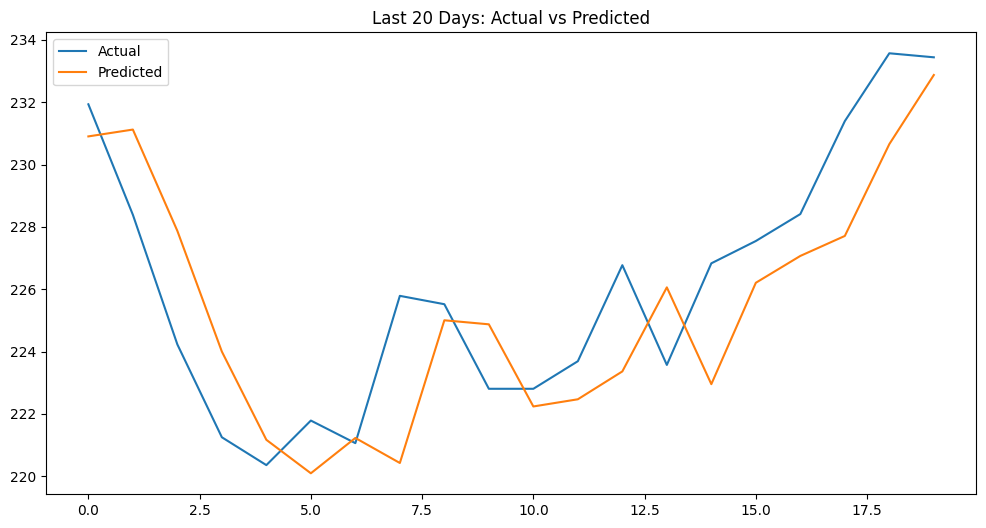

In [20]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[-20:], label="Actual")
plt.plot(predictions[-20:], label="Predicted")
plt.legend()
plt.title("Last 20 Days: Actual vs Predicted")
plt.show()